# 03 — DCF Değerleme Modeli (Base Case)

**Amaç:** Apple'ın hisse başına içsel değerini Discounted Cash Flow (İndirgenmiş Nakit Akışı) yöntemiyle hesaplamak.

**Metodoloji:**
1. **WACC** = Ağırlıklı Ortalama Sermaye Maliyeti (CAPM tabanlı)
2. **FCF Projeksiyonu** = 5 yıllık serbest nakit akışı tahmini
3. **Terminal Value** = Gordon Growth Modeli
4. **Intrinsic Value** = PV(FCF) + PV(TV) - Net Borç

In [10]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from fredapi import Fred

from src.data_fetcher import fetch_apple_beta, fetch_shares_outstanding, FRED_API_KEY
from src.dcf_model import calculate_wacc, project_fcf, terminal_value, intrinsic_value_per_share, sensitivity_table

plt.rcParams['figure.dpi'] = 120
print('Ready.')

Ready.


## 1. Girdi Parametreleri

In [11]:
# Apple son FCF (yfinance'ten veya manuel)
ticker = yf.Ticker('AAPL')
cashflow = ticker.cashflow

if 'Free Cash Flow' in cashflow.index:
    base_fcf = float(cashflow.loc['Free Cash Flow'].iloc[0])
    print(f'Son yıl FCF (yfinance): ${base_fcf/1e9:.1f}B')
else:
    base_fcf = 99_584_000_000  # FY2024 Apple FCF fallback
    print(f'FCF manuel girildi: ${base_fcf/1e9:.1f}B')

# Net borç
balance = ticker.balance_sheet
try:
    total_debt = float(balance.loc['Total Debt'].iloc[0]) if 'Total Debt' in balance.index else 0
    cash = float(balance.loc['Cash And Cash Equivalents'].iloc[0]) if 'Cash And Cash Equivalents' in balance.index else 0
    net_debt = total_debt - cash
    print(f'Toplam Borç: ${total_debt/1e9:.1f}B | Nakit: ${cash/1e9:.1f}B | Net Borç: ${net_debt/1e9:.1f}B')
except:
    net_debt = 36_000_000_000  # Apple FY2024 net debt fallback
    print(f'Net Borç manuel: ${net_debt/1e9:.1f}B')

# Beta ve hisse sayısı
beta = fetch_apple_beta()
shares = fetch_shares_outstanding()
print(f'Beta: {beta:.2f} | Hisse: {shares/1e9:.2f}B')

Son yıl FCF (yfinance): $98.8B
Toplam Borç: $98.7B | Nakit: $35.9B | Net Borç: $62.7B
Beta: 1.06 | Hisse: 14.69B


In [12]:
# Risk-free rate: 10Y ABD Hazine Bonosu (FRED: DGS10)
try:
    fred = Fred(api_key=FRED_API_KEY)
    dgs10 = fred.get_series('DGS10', observation_start='2024-01-01').dropna()
    risk_free_rate = float(dgs10.iloc[-1]) / 100
    print(f'10Y Treasury (FRED, güncel): {risk_free_rate:.2%}')
except Exception as e:
    risk_free_rate = 0.045
    print(f'10Y Treasury (fallback): {risk_free_rate:.2%} | Hata: {e}')

# Base case FCF büyüme oranları (5 yıl)
# Kalibre: Regresyon analizi GDP büyümesi ~%2.5 gösteriyor + Apple'ın geçmiş FCF büyümesi
base_growth_rates = [0.08, 0.08, 0.07, 0.07, 0.06]
terminal_growth_rate = 0.030

print(f'\nBase Case FCF Büyüme Oranları: {[f"{g:.0%}" for g in base_growth_rates]}')
print(f'Terminal Growth Rate: {terminal_growth_rate:.1%}')

10Y Treasury (FRED, güncel): 4.45%

Base Case FCF Büyüme Oranları: ['8%', '8%', '7%', '7%', '6%']
Terminal Growth Rate: 3.0%


## 2. WACC Hesabı

In [13]:
wacc = calculate_wacc(
    risk_free_rate=risk_free_rate,
    beta=beta,
    market_risk_premium=0.055,
    debt_weight=0.25,
    cost_of_debt=0.035,
    tax_rate=0.21
)

cost_of_equity = risk_free_rate + beta * 0.055

print('=' * 45)
print('           WACC HESABI')
print('=' * 45)
print(f'Risk-Free Rate (Rf)        : {risk_free_rate:.2%}')
print(f'Beta (β)                   : {beta:.2f}')
print(f'Market Risk Premium (MRP)  : 5.50%')
print(f'Cost of Equity (Ke)        : {cost_of_equity:.2%}')
print(f'Cost of Debt (Kd)          : 3.50%')
print(f'Tax Rate                   : 21.00%')
print(f'Equity Weight              : 75%')
print(f'Debt Weight                : 25%')
print('-' * 45)
print(f'WACC                       : {wacc:.2%}')
print('=' * 45)

           WACC HESABI
Risk-Free Rate (Rf)        : 4.45%
Beta (β)                   : 1.06
Market Risk Premium (MRP)  : 5.50%
Cost of Equity (Ke)        : 10.31%
Cost of Debt (Kd)          : 3.50%
Tax Rate                   : 21.00%
Equity Weight              : 75%
Debt Weight                : 25%
---------------------------------------------
WACC                       : 8.42%


## 3. FCF Projeksiyonu & İndirgenmiş Değerler

In [14]:
result = intrinsic_value_per_share(
    base_fcf=base_fcf,
    growth_rates=base_growth_rates,
    wacc=wacc,
    terminal_growth=terminal_growth_rate,
    net_debt=net_debt,
    shares_outstanding=shares
)

years = list(range(1, len(base_growth_rates) + 1))
projection_df = pd.DataFrame({
    'Yıl': [f'Y+{y}' for y in years],
    'Büyüme Oranı': [f'{g:.0%}' for g in base_growth_rates],
    'Projeksiyon FCF ($B)': [round(f / 1e9, 2) for f in result['projected_fcfs']],
    'İndirgenmiş PV ($B)': [round(p / 1e9, 2) for p in result['pv_fcfs']],
})
print(projection_df.to_string(index=False))
print(f'\nFCF PV Toplamı: ${result["sum_pv_fcfs"]/1e9:.1f}B')

Yıl Büyüme Oranı  Projeksiyon FCF ($B)  İndirgenmiş PV ($B)
Y+1           8%                106.67                98.38
Y+2           8%                115.20                98.00
Y+3           7%                123.27                96.71
Y+4           7%                131.89                95.45
Y+5           6%                139.81                93.31

FCF PV Toplamı: $481.9B


## 4. Terminal Value & Değerleme Özeti

In [15]:
# Mevcut piyasa fiyatı
current_price = ticker.info.get('currentPrice', ticker.info.get('regularMarketPrice', None))

print('=' * 50)
print('        DCF DEĞERLEME ÖZETI (BASE CASE)')
print('=' * 50)
print(f'FCF PV Toplamı (5Y)     : ${result["sum_pv_fcfs"]/1e9:.1f}B')
print(f'Terminal Value (TV)     : ${result["terminal_value"]/1e9:.1f}B')
print(f'PV(Terminal Value)      : ${result["pv_terminal_value"]/1e9:.1f}B')
print('-' * 50)
print(f'Enterprise Value (EV)   : ${result["enterprise_value"]/1e9:.1f}B')
print(f'(-) Net Borç            : ${net_debt/1e9:.1f}B')
print(f'Equity Value            : ${result["equity_value"]/1e9:.1f}B')
print(f'Hisse Sayısı            : {shares/1e9:.2f}B')
print('=' * 50)
print(f'İÇSEL DEĞER / HİSSE     : ${result["intrinsic_value_per_share"]:.2f}')
if current_price:
    updown = ((result['intrinsic_value_per_share'] / current_price) - 1) * 100
    print(f'Mevcut Fiyat            : ${current_price:.2f}')
    print(f'Yukarı/Aşağı Potansiyel : {updown:+.1f}%')
print('=' * 50)

        DCF DEĞERLEME ÖZETI (BASE CASE)
FCF PV Toplamı (5Y)     : $481.9B
Terminal Value (TV)     : $2656.0B
PV(Terminal Value)      : $1772.7B
--------------------------------------------------
Enterprise Value (EV)   : $2254.6B
(-) Net Borç            : $62.7B
Equity Value            : $2191.8B
Hisse Sayısı            : 14.69B
İÇSEL DEĞER / HİSSE     : $149.23
Mevcut Fiyat            : $312.06
Yukarı/Aşağı Potansiyel : -52.2%


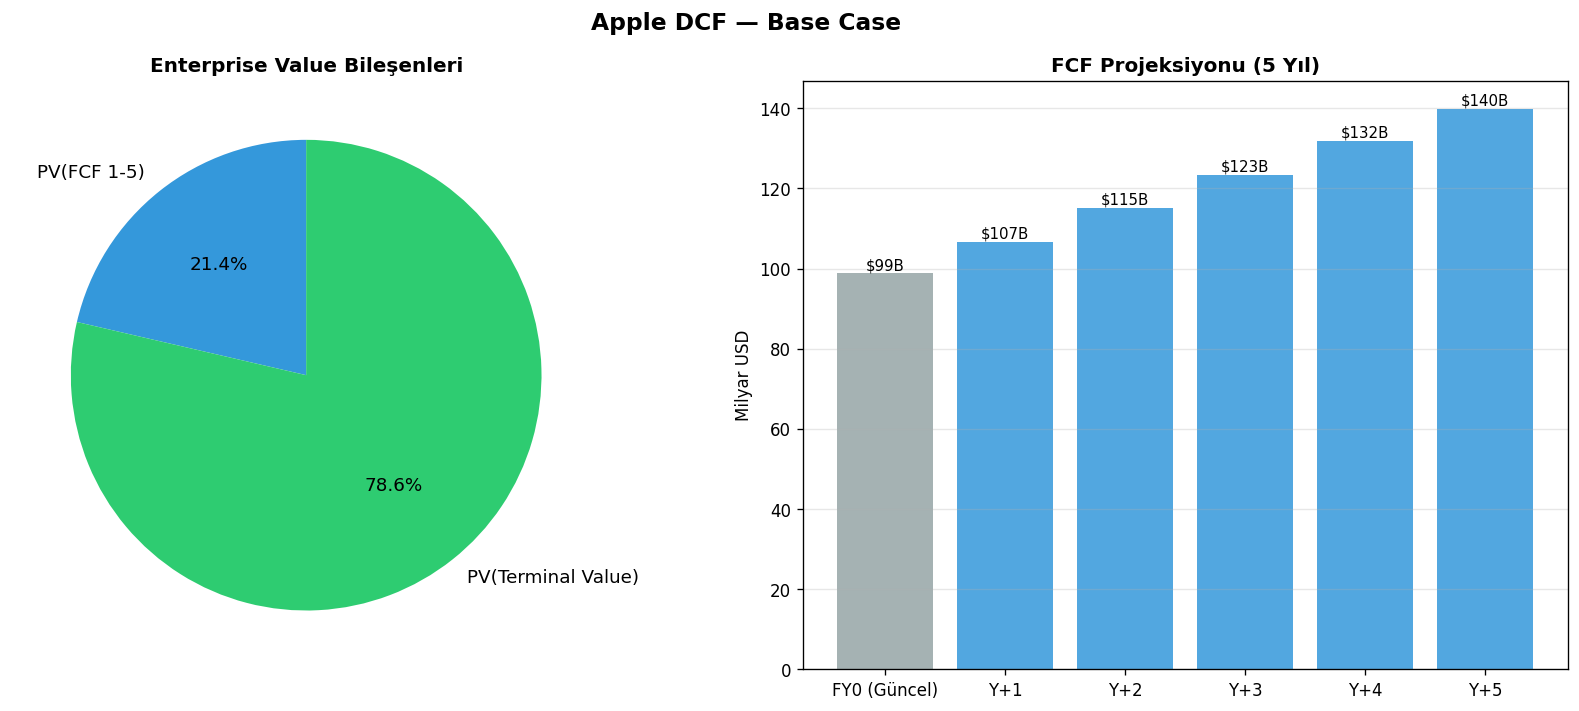

In [16]:
# Değer dağılımı pasta grafiği (FCF vs Terminal)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol: EV bileşenleri
labels = ['PV(FCF 1-5)', 'PV(Terminal Value)']
sizes = [result['sum_pv_fcfs'], result['pv_terminal_value']]
colors = ['#3498db', '#2ecc71']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Enterprise Value Bileşenleri', fontweight='bold')

# Sağ: FCF waterfall
fcf_values = [base_fcf / 1e9] + [f / 1e9 for f in result['projected_fcfs']]
fcf_labels = ['FY0 (Güncel)'] + [f'Y+{i+1}' for i in range(len(base_growth_rates))]
bar_colors = ['#95a5a6'] + ['#3498db'] * len(base_growth_rates)

axes[1].bar(fcf_labels, fcf_values, color=bar_colors, alpha=0.85)
for i, v in enumerate(fcf_values):
    axes[1].text(i, v + 1, f'${v:.0f}B', ha='center', fontsize=9)
axes[1].set_title('FCF Projeksiyonu (5 Yıl)', fontweight='bold')
axes[1].set_ylabel('Milyar USD')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Apple DCF — Base Case', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/dcf_base_case.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sensitivite Tablosu: WACC × Terminal Growth Rate

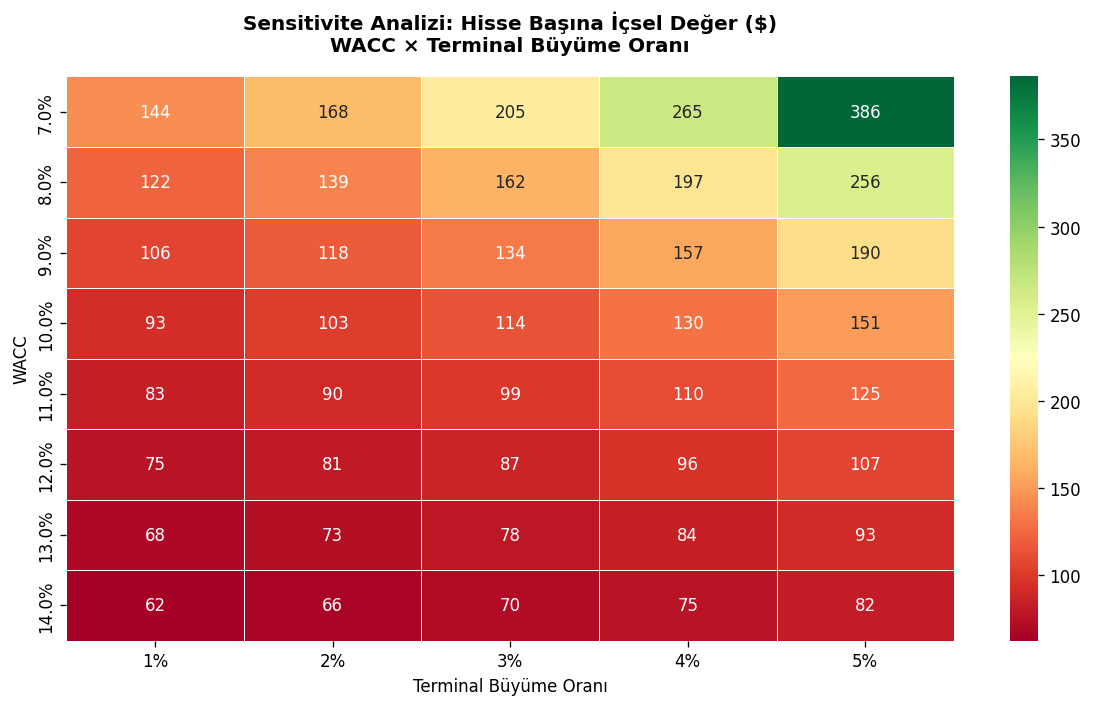

Terminal Growth,1%,2%,3%,4%,5%
WACC,,,,,
7.0%,144.10,168.31,204.62,265.14,386.17
8.0%,122.39,139.05,162.38,197.36,255.67
9.0%,106.13,118.17,134.23,156.71,190.42
10.0%,93.49,102.52,114.13,129.61,151.28
11.0%,83.39,90.36,99.07,110.27,125.20
12.0%,75.14,80.64,87.36,95.77,106.57
13.0%,68.27,72.70,78.00,84.49,92.60
14.0%,62.47,66.08,70.35,75.48,81.74


In [17]:
sens_table = sensitivity_table(
    base_fcf=base_fcf,
    growth_rates=base_growth_rates,
    net_debt=net_debt,
    shares_outstanding=shares,
    beta=beta
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    sens_table.astype(float),
    annot=True, fmt='.0f', cmap='RdYlGn',
    ax=ax, linewidths=0.5,
    annot_kws={'size': 10}
)
ax.set_title('Sensitivite Analizi: Hisse Başına İçsel Değer ($)\nWACC × Terminal Büyüme Oranı', 
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Terminal Büyüme Oranı')
ax.set_ylabel('WACC')
plt.tight_layout()
plt.savefig('../data/processed/sensitivity_table.png', dpi=150, bbox_inches='tight')
plt.show()

sens_table

In [18]:
# Özet tablosu — gerçek hesaplanan değerler
from IPython.display import display
import pandas as pd

summary_data = {
    'Parametre': ['WACC', '5Y FCF Büyüme', 'Terminal Growth', 'İçsel Değer / Hisse'],
    'Değer': [
        f"{result['wacc']:.2%}",
        '%8 → %6',
        f"{terminal_growth_rate:.1%}",
        f"${result['intrinsic_value_per_share']:.2f}"
    ]
}
summary_df = pd.DataFrame(summary_data).set_index('Parametre')
display(summary_df)

if current_price:
    print(f"\nMevcut Piyasa Fiyatı : ${current_price:.2f}")
    updown = ((result['intrinsic_value_per_share'] / current_price) - 1) * 100
    print(f"Yukarı/Aşağı Potansiyel: {updown:+.1f}%")

print('\nSonraki adım: 04_scenario_analysis.ipynb — Bull / Base / Bear senaryolarının karşılaştırması.')

,Değer
Parametre,
WACC,8.42%
5Y FCF Büyüme,%8 → %6
Terminal Growth,3.0%
İçsel Değer / Hisse,$149.23



Mevcut Piyasa Fiyatı : $312.06
Yukarı/Aşağı Potansiyel: -52.2%

Sonraki adım: 04_scenario_analysis.ipynb — Bull / Base / Bear senaryolarının karşılaştırması.
